# II. Khám phá dữ liệu

Phần này thực hiện khám phá toàn diện về cấu trúc, chất lượng và đặc điểm của bộ dữ liệu để hiểu rõ dữ liệu đang làm việc và xác định các vấn đề tiềm ẩn.

## 2.1 Tổng quan về bộ dữ liệu

### Import thư viện cần thiết

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

### Tải dữ liệu

In [35]:
df_2025 = pd.read_csv('../dataset/spotify_data clean.csv')
df_2009_2023 = pd.read_csv('../dataset/track_data_final.csv')

### Thông tin cơ bản

Kiểm tra số lượng dòng, số lượng cột, kích thước tổng thể và kiểu dữ liệu của từng cột.

In [36]:
print("Bộ dữ liệu 2025 - Thông tin cơ bản")
print(f"Số lượng dòng: {df_2025.shape[0]:,}")
print(f"Số lượng cột: {df_2025.shape[1]}")
print(f"Kích thước: {df_2025.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nKiểu dữ liệu:")
print(df_2025.dtypes)

Bộ dữ liệu 2025 - Thông tin cơ bản
Số lượng dòng: 8,582
Số lượng cột: 15
Kích thước: 4.56 MB

Kiểu dữ liệu:
track_id               object
track_name             object
track_number            int64
track_popularity        int64
explicit                 bool
artist_name            object
artist_popularity       int64
artist_followers        int64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
track_duration_min    float64
dtype: object


In [37]:
print("Bộ dữ liệu 2009-2023 - Thông tin cơ bản")
print(f"Số lượng dòng: {df_2009_2023.shape[0]:,}")
print(f"Số lượng cột: {df_2009_2023.shape[1]}")
print(f"Kích thước: {df_2009_2023.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nKiểu dữ liệu:")
print(df_2009_2023.dtypes)

Bộ dữ liệu 2009-2023 - Thông tin cơ bản
Số lượng dòng: 8,778
Số lượng cột: 15
Kích thước: 4.72 MB

Kiểu dữ liệu:
track_id               object
track_name             object
track_number            int64
track_popularity        int64
track_duration_ms       int64
explicit                 bool
artist_name            object
artist_popularity     float64
artist_followers      float64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
dtype: object


Mỗi dòng trong bộ dữ liệu đại diện cho một bài hát (track) trên Spotify cùng với thông tin về nghệ sĩ và album chứa bài hát đó.

### Tính toàn vẹn dữ liệu

Kiểm tra các dòng trùng lặp và dòng trống hoàn toàn.

In [38]:
duplicates_by_id = df_2025[df_2025.duplicated(subset=['track_id'], keep=False)]
duplicates_full = df_2025[df_2025.duplicated(keep='first')]
completely_empty = df_2025[df_2025.isnull().all(axis=1)]

print("Bộ dữ liệu 2025 - Tính toàn vẹn")
print(f"Dòng trùng lặp theo track_id: {len(duplicates_by_id):,}")
print(f"Dòng trùng lặp hoàn toàn: {len(duplicates_full):,}")
print(f"Dòng trống hoàn toàn: {len(completely_empty):,}")

Bộ dữ liệu 2025 - Tính toàn vẹn
Dòng trùng lặp theo track_id: 0
Dòng trùng lặp hoàn toàn: 0
Dòng trống hoàn toàn: 0


In [39]:
duplicates_by_id = df_2009_2023[df_2009_2023.duplicated(subset=['track_id'], keep=False)]
duplicates_full = df_2009_2023[df_2009_2023.duplicated(keep='first')]
completely_empty = df_2009_2023[df_2009_2023.isnull().all(axis=1)]

print("Bộ dữ liệu 2009-2023 - Tính toàn vẹn")
print(f"Dòng trùng lặp theo track_id: {len(duplicates_by_id):,}")
print(f"Dòng trùng lặp hoàn toàn: {len(duplicates_full):,}")
print(f"Dòng trống hoàn toàn: {len(completely_empty):,}")

Bộ dữ liệu 2009-2023 - Tính toàn vẹn
Dòng trùng lặp theo track_id: 0
Dòng trùng lặp hoàn toàn: 0
Dòng trống hoàn toàn: 0


Không phát hiện dòng trùng lặp hay dòng trống, chứng tỏ dữ liệu có chất lượng tốt về mặt toàn vẹn.

### Danh mục cột

Liệt kê tất cả các cột trong mỗi bộ dữ liệu.

In [40]:
print("Bộ dữ liệu 2025 - Danh sách cột:")
for i, col in enumerate(df_2025.columns, 1):
    print(f"  {i:2}. {col}")

Bộ dữ liệu 2025 - Danh sách cột:
   1. track_id
   2. track_name
   3. track_number
   4. track_popularity
   5. explicit
   6. artist_name
   7. artist_popularity
   8. artist_followers
   9. artist_genres
  10. album_id
  11. album_name
  12. album_release_date
  13. album_total_tracks
  14. album_type
  15. track_duration_min


In [41]:
print("Bộ dữ liệu 2009-2023 - Danh sách cột:")
for i, col in enumerate(df_2009_2023.columns, 1):
    print(f"  {i:2}. {col}")

Bộ dữ liệu 2009-2023 - Danh sách cột:
   1. track_id
   2. track_name
   3. track_number
   4. track_popularity
   5. track_duration_ms
   6. explicit
   7. artist_name
   8. artist_popularity
   9. artist_followers
  10. artist_genres
  11. album_id
  12. album_name
  13. album_release_date
  14. album_total_tracks
  15. album_type


### Ý nghĩa của các cột

**Các cột quan trọng cần giữ lại:**

**Thông tin định danh:**
- `track_id`: Mã định danh duy nhất của bài hát
- `track_name`: Tên bài hát
- `artist_name`: Tên nghệ sĩ

**Chỉ số độ phổ biến:**
- `track_popularity`: Độ phổ biến của bài hát (0-100)
- `artist_popularity`: Độ phổ biến của nghệ sĩ (0-100)
- `artist_followers`: Số người theo dõi nghệ sĩ

**Đặc điểm âm nhạc:**
- `track_duration_ms` / `track_duration_min`: Thời lượng bài hát
- `explicit`: Có nội dung tường minh hay không
- `artist_genres`: Thể loại âm nhạc

**Thông tin thời gian:**
- `album_release_date`: Ngày phát hành album

**Các cột có thể xóa:**
- `track_number`: Thứ tự trong album, ít ảnh hưởng đến phân tích
- `album_id`: Có thể thay thế bằng `album_name`
- `album_name`: Ít giá trị vì người nghe thường nghe từng bài riêng lẻ

**Các cột cần cân nhắc:**
- `album_total_tracks`: Có thể tạo feature `is_single`
- `album_type`: Có thể phân biệt single vs album vs compilation

### Phân tích kiểu dữ liệu

Kiểm tra kiểu dữ liệu hiện tại và xác định các cột cần chuyển đổi.

In [42]:
print("Bộ dữ liệu 2025 - Kiểu dữ liệu:")
for col in df_2025.columns:
    print(f"  {col:25}: {df_2025[col].dtype}")

Bộ dữ liệu 2025 - Kiểu dữ liệu:
  track_id                 : object
  track_name               : object
  track_number             : int64
  track_popularity         : int64
  explicit                 : bool
  artist_name              : object
  artist_popularity        : int64
  artist_followers         : int64
  artist_genres            : object
  album_id                 : object
  album_name               : object
  album_release_date       : object
  album_total_tracks       : int64
  album_type               : object
  track_duration_min       : float64


In [43]:
print("Bộ dữ liệu 2009-2023 - Kiểu dữ liệu:")
for col in df_2009_2023.columns:
    print(f"  {col:25}: {df_2009_2023[col].dtype}")

Bộ dữ liệu 2009-2023 - Kiểu dữ liệu:
  track_id                 : object
  track_name               : object
  track_number             : int64
  track_popularity         : int64
  track_duration_ms        : int64
  explicit                 : bool
  artist_name              : object
  artist_popularity        : float64
  artist_followers         : float64
  artist_genres            : object
  album_id                 : object
  album_name               : object
  album_release_date       : object
  album_total_tracks       : int64
  album_type               : object


**Vấn đề về kiểu dữ liệu:**

1. `artist_popularity` và `artist_followers` không nhất quán giữa hai bộ dữ liệu (int64 vs float64)
2. `track_duration_ms` và `track_duration_min` khác đơn vị cần chuẩn hóa về cùng một đơn vị

Cần chuyển đổi để đảm bảo tính nhất quán khi phân tích.

### Chuẩn hóa kiểu dữ liệu

Chuyển đổi các cột về kiểu dữ liệu phù hợp và chuẩn hóa đơn vị.

In [44]:
df_2025['artist_popularity'] = df_2025['artist_popularity'].fillna(0).astype('int64')
df_2025['artist_followers'] = df_2025['artist_followers'].fillna(0).astype('int64')

df_2009_2023['artist_popularity'] = df_2009_2023['artist_popularity'].fillna(0).astype('int64')
df_2009_2023['artist_followers'] = df_2009_2023['artist_followers'].fillna(0).astype('int64')

df_2009_2023['track_duration_min'] = df_2009_2023['track_duration_ms'] / 60000.0
df_2009_2023 = df_2009_2023.drop(columns=['track_duration_ms'])

## 2.2 Phân tích các cột số

### Xác định các cột số

In [45]:
numerical_cols_2025 = df_2025.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols_2009 = df_2009_2023.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Bộ dữ liệu 2025 - Các cột số:")
for i, col in enumerate(numerical_cols_2025, 1):
    print(f"  {i}. {col}")

print("\nBộ dữ liệu 2009-2023 - Các cột số:")
for i, col in enumerate(numerical_cols_2009, 1):
    print(f"  {i}. {col}")

Bộ dữ liệu 2025 - Các cột số:
  1. track_number
  2. track_popularity
  3. artist_popularity
  4. artist_followers
  5. album_total_tracks
  6. track_duration_min

Bộ dữ liệu 2009-2023 - Các cột số:
  1. track_number
  2. track_popularity
  3. artist_popularity
  4. artist_followers
  5. album_total_tracks
  6. track_duration_min


### Thống kê mô tả

Tính toán giá trị trung bình, trung vị và độ lệch chuẩn cho các cột số.

In [46]:
stats_2025 = df_2025[numerical_cols_2025].agg(['mean', 'median', 'std'])
stats_2009 = df_2009_2023[numerical_cols_2009].agg(['mean', 'median', 'std'])

print("Bộ dữ liệu 2025:")
print(stats_2025.round(2))

print("\nBộ dữ liệu 2009-2023:")
print(stats_2009.round(2))

Bộ dữ liệu 2025:
        track_number  track_popularity  artist_popularity  artist_followers  \
mean            5.77             52.36              69.73       24034719.33   
median          4.00             58.00              74.00        6105547.00   
std             6.05             23.82              19.65       38031804.96   

        album_total_tracks  track_duration_min  
mean                 13.79                3.49  
median               13.00                3.44  
std                  11.89                1.06  

Bộ dữ liệu 2009-2023:
        track_number  track_popularity  artist_popularity  artist_followers  \
mean            5.75             52.23              69.92       24343767.66   
median          4.00             58.00              74.00        6223889.50   
std             6.02             24.08              19.59       38132537.98   

        album_total_tracks  track_duration_min  
mean                 13.78                3.50  
median               13.00      

### Phân bố dữ liệu

Vẽ biểu đồ histogram và đường mật độ xác suất (KDE) để quan sát phân bố của các cột số.

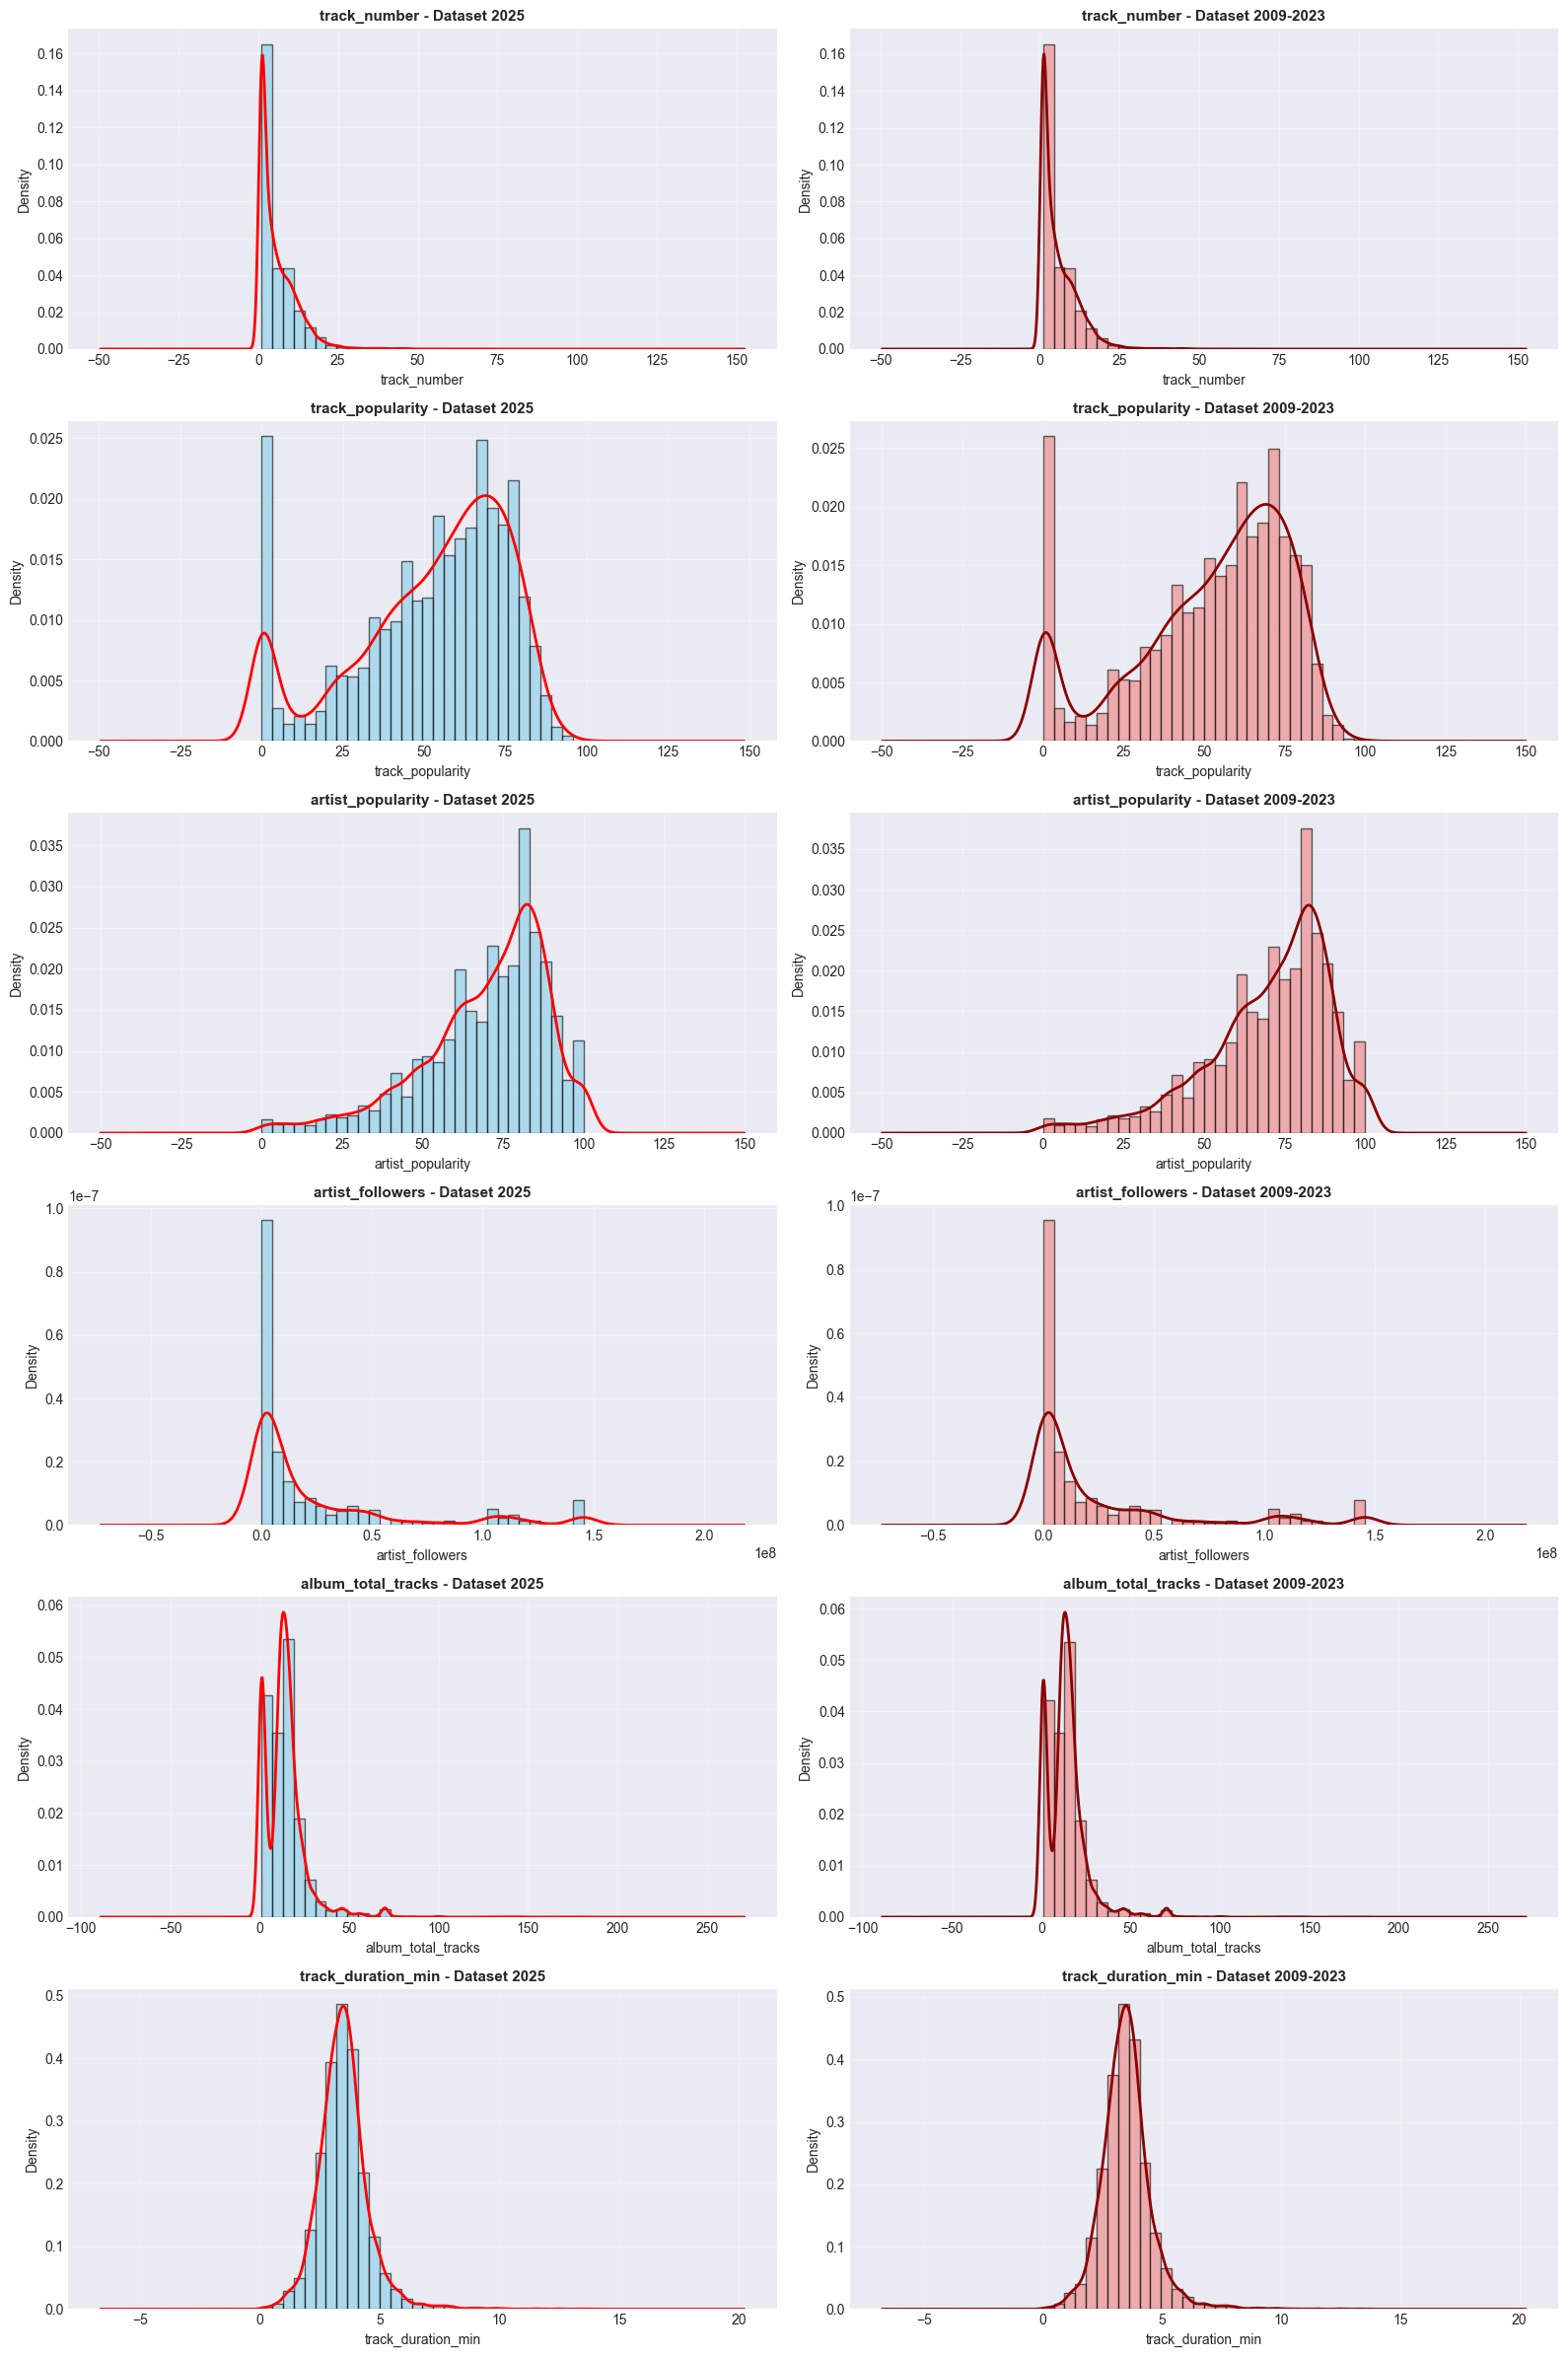

In [47]:
fig, axes = plt.subplots(len(numerical_cols_2025), 2, figsize=(16, 4*len(numerical_cols_2025)))

for i, col in enumerate(numerical_cols_2025):
    data_2025 = df_2025[col].dropna()
    axes[i, 0].hist(data_2025, bins=30, edgecolor='black', alpha=0.6, density=True, color='skyblue')
    data_2025.plot(kind='kde', ax=axes[i, 0], color='red', linewidth=2)
    axes[i, 0].set_title(f'{col} - Dataset 2025', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel(col, fontsize=10)
    axes[i, 0].set_ylabel('Density', fontsize=10)
    axes[i, 0].grid(alpha=0.3)
    
    if col in numerical_cols_2009:
        data_2009 = df_2009_2023[col].dropna()
        axes[i, 1].hist(data_2009, bins=30, edgecolor='black', alpha=0.6, density=True, color='lightcoral')
        data_2009.plot(kind='kde', ax=axes[i, 1], color='darkred', linewidth=2)
        axes[i, 1].set_title(f'{col} - Dataset 2009-2023', fontsize=11, fontweight='bold')
        axes[i, 1].set_xlabel(col, fontsize=10)
        axes[i, 1].set_ylabel('Density', fontsize=10)
        axes[i, 1].grid(alpha=0.3)
    else:
        axes[i, 1].text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=12)
        axes[i, 1].set_title(f'{col} - N/A', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Các biểu đồ phân bố cho thấy hình dạng phân phối của từng biến số. Phần lớn các biến có phân bố lệch phải, đặc biệt là `artist_followers` và các chỉ số popularity.

### Phân tích hình dạng phân bố

Tính toán độ lệch (skewness) và độ nhọn (kurtosis) để xác định hình dạng phân bố.

In [48]:
shape_analysis = []

for col in sorted(numerical_cols_2025):
    data_2025 = df_2025[col].dropna()
    skew_2025 = stats.skew(data_2025)
    kurt_2025 = stats.kurtosis(data_2025)
    
    if abs(skew_2025) < 0.5 and abs(kurt_2025) < 1:
        shape_2025 = "phan bo chuan"
    elif skew_2025 > 1:
        shape_2025 = "lech phai"
    elif skew_2025 < -1:
        shape_2025 = "lech trai"
    else:
        shape_2025 = "lech vua phai"
    
    if col in df_2009_2023.columns:
        data_2009 = df_2009_2023[col].dropna()
        skew_2009 = stats.skew(data_2009)
        kurt_2009 = stats.kurtosis(data_2009)
        
        if abs(skew_2009) < 0.5 and abs(kurt_2009) < 1:
            shape_2009 = "phan bo chuan"
        elif skew_2009 > 1:
            shape_2009 = "lech phai"
        elif skew_2009 < -1:
            shape_2009 = "lech trai"
        else:
            shape_2009 = "lech vua phai"
    else:
        skew_2009, kurt_2009, shape_2009 = 0, 0, "N/A"
    
    shape_analysis.append({
        'Column': col,
        'Skew_2025': skew_2025,
        'Kurt_2025': kurt_2025,
        'Shape_2025': shape_2025,
        'Skew_2009': skew_2009,
        'Kurt_2009': kurt_2009,
        'Shape_2009': shape_2009
    })

pd.DataFrame(shape_analysis)

,Column,Skew_2025,Kurt_2025,Shape_2025,Skew_2009,Kurt_2009,Shape_2009
0,album_total_tracks,2.87,18.46,lech phai,2.87,18.64,lech phai
1,artist_followers,1.96,2.85,lech phai,1.93,2.74,lech phai
2,artist_popularity,-1.04,1.02,lech trai,-1.06,1.09,lech trai
3,track_duration_min,1.28,7.04,lech phai,1.27,6.99,lech phai
4,track_number,2.65,16.50,lech phai,2.66,16.57,lech phai
5,track_popularity,-0.78,-0.24,lech vua phai,-0.78,-0.28,lech vua phai


Hầu hết các biến có độ lệch dương, cho thấy có nhiều giá trị nhỏ và một số giá trị lớn bất thường (outliers).

### Khoảng giá trị và giá trị ngoại lai

Kiểm tra giá trị min, max và xác định outliers bằng phương pháp IQR.

In [49]:
range_analysis = []

for col in sorted(numerical_cols_2025):
    min_2025 = df_2025[col].min()
    max_2025 = df_2025[col].max()
    range_2025 = max_2025 - min_2025
    
    if col in df_2009_2023.columns:
        min_2009 = df_2009_2023[col].min()
        max_2009 = df_2009_2023[col].max()
        range_2009 = max_2009 - min_2009
    else:
        min_2009, max_2009, range_2009 = None, None, None
    
    range_analysis.append({
        'Column': col,
        'Min_2025': min_2025,
        'Max_2025': max_2025,
        'Range_2025': range_2025,
        'Min_2009': min_2009,
        'Max_2009': max_2009,
        'Range_2009': range_2009
    })

pd.DataFrame(range_analysis)

,Column,Min_2025,Max_2025,Range_2025,Min_2009,Max_2009,Range_2009
0,album_total_tracks,1.00,181.00,180.00,1.00,181.00,180.00
1,artist_followers,0.00,145542136.00,145542136.00,0.00,145542136.00,145542136.00
2,artist_popularity,0.00,100.00,100.00,0.00,100.00,100.00
3,track_duration_min,0.07,13.51,13.44,0.00,13.52,13.52
4,track_number,1.00,102.00,101.00,1.00,102.00,101.00
5,track_popularity,0.00,99.00,99.00,0.00,100.00,100.00


Tất cả các giá trị đều nằm trong khoảng hợp lý. Các chỉ số popularity nằm trong [0, 100] theo định nghĩa của Spotify.

### Phát hiện outliers bằng IQR

Sử dụng phương pháp IQR (Interquartile Range) để phát hiện các giá trị ngoại lai.

$$\text{Lower Bound} = Q1 - 1.5 \times IQR$$
$$\text{Upper Bound} = Q3 + 1.5 \times IQR$$

Giá trị nào nằm ngoài khoảng [Lower Bound, Upper Bound] được coi là outlier.

In [50]:
outlier_analysis = []

for col in sorted(numerical_cols_2025):
    q1_2025 = df_2025[col].quantile(0.25)
    q3_2025 = df_2025[col].quantile(0.75)
    iqr_2025 = q3_2025 - q1_2025
    lower_2025 = q1_2025 - 1.5 * iqr_2025
    upper_2025 = q3_2025 + 1.5 * iqr_2025
    outliers_2025 = ((df_2025[col] < lower_2025) | (df_2025[col] > upper_2025)).sum()
    non_null_2025 = df_2025[col].notna().sum()
    outlier_pct_2025 = (outliers_2025 / non_null_2025) * 100 if non_null_2025 > 0 else 0
    
    if col in df_2009_2023.columns:
        q1_2009 = df_2009_2023[col].quantile(0.25)
        q3_2009 = df_2009_2023[col].quantile(0.75)
        iqr_2009 = q3_2009 - q1_2009
        lower_2009 = q1_2009 - 1.5 * iqr_2009
        upper_2009 = q3_2009 + 1.5 * iqr_2009
        outliers_2009 = ((df_2009_2023[col] < lower_2009) | (df_2009_2023[col] > upper_2009)).sum()
        non_null_2009 = df_2009_2023[col].notna().sum()
        outlier_pct_2009 = (outliers_2009 / non_null_2009) * 100 if non_null_2009 > 0 else 0
    else:
        q1_2009, q3_2009, iqr_2009 = None, None, None
        outliers_2009, outlier_pct_2009 = None, None
    
    outlier_analysis.append({
        'Column': col,
        'Q1_2025': q1_2025,
        'Q3_2025': q3_2025,
        'IQR_2025': iqr_2025,
        'Outliers_2025': outliers_2025,
        'Outlier_Pct_2025': outlier_pct_2025,
        'Q1_2009': q1_2009,
        'Q3_2009': q3_2009,
        'IQR_2009': iqr_2009,
        'Outliers_2009': outliers_2009,
        'Outlier_Pct_2009': outlier_pct_2009
    })

pd.DataFrame(outlier_analysis)

,Column,Q1_2025,Q3_2025,IQR_2025,Outliers_2025,Outlier_Pct_2025,Q1_2009,Q3_2009,IQR_2009,Outliers_2009,Outlier_Pct_2009
0,album_total_tracks,6.00,17.00,11.00,379,4.42,6.00,17.00,11.00,380,4.33
1,artist_followers,462320.00,27252551.00,26790231.00,1044,12.16,512702.50,30550549.00,30037846.50,999,11.38
2,artist_popularity,60.00,84.00,24.00,286,3.33,60.00,84.00,24.00,289,3.29
3,track_duration_min,2.88,3.99,1.11,358,4.17,2.90,3.99,1.10,377,4.29
4,track_number,1.00,9.00,8.00,166,1.93,1.00,9.00,8.00,168,1.91
5,track_popularity,39.00,71.00,32.00,0,0.00,39.00,71.00,32.00,0,0.00


Các outliers có thể là giá trị hợp lý (như nghệ sĩ siêu nổi tiếng có số followers rất cao) hoặc lỗi dữ liệu. Cần xem xét từng trường hợp cụ thể trong bước tiền xử lý.

### Kiểm tra giá trị thiếu trong các cột số

In [51]:
missing_numerical = pd.DataFrame({
    'Column': numerical_cols_2025,
    'Missing_2025': [df_2025[col].isnull().sum() for col in numerical_cols_2025],
    'Pct_2025': [(df_2025[col].isnull().sum() / len(df_2025)) * 100 for col in numerical_cols_2025]
})

missing_numerical_2009 = pd.DataFrame({
    'Column': numerical_cols_2009,
    'Missing_2009': [df_2009_2023[col].isnull().sum() for col in numerical_cols_2009],
    'Pct_2009': [(df_2009_2023[col].isnull().sum() / len(df_2009_2023)) * 100 for col in numerical_cols_2009]
})

print("Bộ dữ liệu 2025:")
print(missing_numerical)

print("\nBộ dữ liệu 2009-2023:")
print(missing_numerical_2009)

Bộ dữ liệu 2025:
               Column  Missing_2025  Pct_2025
0        track_number             0      0.00
1    track_popularity             0      0.00
2   artist_popularity             0      0.00
3    artist_followers             0      0.00
4  album_total_tracks             0      0.00
5  track_duration_min             0      0.00

Bộ dữ liệu 2009-2023:
               Column  Missing_2009  Pct_2009
0        track_number             0      0.00
1    track_popularity             0      0.00
2   artist_popularity             0      0.00
3    artist_followers             0      0.00
4  album_total_tracks             0      0.00
5  track_duration_min             0      0.00


Các cột số không có giá trị thiếu, cho thấy dữ liệu số có chất lượng tốt.

### Kiểm tra giá trị placeholder

Kiểm tra các giá trị đặc biệt có thể là placeholder cho missing values như 0, -1, hoặc 999.

In [52]:
placeholder_check = []

for col in sorted(numerical_cols_2025):
    zeros_2025 = (df_2025[col] == 0).sum()
    negones_2025 = (df_2025[col] == -1).sum()
    nines_2025 = (df_2025[col] == 999).sum()
    
    if col in df_2009_2023.columns:
        zeros_2009 = (df_2009_2023[col] == 0).sum()
        negones_2009 = (df_2009_2023[col] == -1).sum()
        nines_2009 = (df_2009_2023[col] == 999).sum()
    else:
        zeros_2009, negones_2009, nines_2009 = 0, 0, 0
    
    placeholder_check.append({
        'Column': col,
        'Zeros_2025': zeros_2025,
        'Neg1_2025': negones_2025,
        'N999_2025': nines_2025,
        'Zeros_2009': zeros_2009,
        'Neg1_2009': negones_2009,
        'N999_2009': nines_2009
    })

pd.DataFrame(placeholder_check)

,Column,Zeros_2025,Neg1_2025,N999_2025,Zeros_2009,Neg1_2009,N999_2009
0,album_total_tracks,0,0,0,0,0,0
1,artist_followers,8,0,0,9,0,0
2,artist_popularity,25,0,0,28,0,0
3,track_duration_min,0,0,0,2,0,0
4,track_number,0,0,0,0,0,0
5,track_popularity,503,0,0,521,0,0


Giá trị 0 xuất hiện khá nhiều trong `track_popularity` và `artist_popularity`, đây là giá trị hợp lý cho các bài hát hoặc nghệ sĩ chưa nổi tiếng. Không phát hiện các placeholder bất thường như -1 hoặc 999.

### Kiểm tra giá trị không hợp lệ

Kiểm tra các giá trị nằm ngoài khoảng hợp lý theo định nghĩa của từng biến.

In [53]:
print("Kiem tra gia tri popularity nam ngoai [0, 100]:")
for col in ['track_popularity', 'artist_popularity']:
    invalid_2025 = df_2025[(df_2025[col] < 0) | (df_2025[col] > 100)][col].count()
    invalid_2009 = df_2009_2023[(df_2009_2023[col] < 0) | (df_2009_2023[col] > 100)][col].count()
    print(f"  {col}: {invalid_2025:,} (2025), {invalid_2009:,} (2009-2023)")

print("\nKiem tra gia tri am:")
for col in ['artist_followers', 'album_total_tracks', 'track_number']:
    negative_2025 = df_2025[df_2025[col] < 0][col].count()
    if col in df_2009_2023.columns:
        negative_2009 = df_2009_2023[df_2009_2023[col] < 0][col].count()
        print(f"  {col}: {negative_2025:,} (2025), {negative_2009:,} (2009-2023)")
    else:
        print(f"  {col}: {negative_2025:,} (2025)")

print("\nKiem tra thoi luong bat thuong:")
col = 'track_duration_min'
zero_2025 = df_2025[df_2025[col] <= 0][col].count()
unreasonable_2025 = df_2025[(df_2025[col] > 0) & ((df_2025[col] < 0.5) | (df_2025[col] > 30))][col].count()
zero_2009 = df_2009_2023[df_2009_2023[col] <= 0][col].count()
unreasonable_2009 = df_2009_2023[(df_2009_2023[col] > 0) & ((df_2009_2023[col] < 0.5) | (df_2009_2023[col] > 30))][col].count()
print(f"  Thoi luong bang 0 hoac am: {zero_2025:,} (2025), {zero_2009:,} (2009-2023)")
print(f"  Thoi luong bat thuong (<0.5 phut hoac >30 phut): {unreasonable_2025:,} (2025), {unreasonable_2009:,} (2009-2023)")

Kiem tra gia tri popularity nam ngoai [0, 100]:
  track_popularity: 0 (2025), 0 (2009-2023)
  artist_popularity: 0 (2025), 0 (2009-2023)

Kiem tra gia tri am:
  artist_followers: 0 (2025), 0 (2009-2023)
  album_total_tracks: 0 (2025), 0 (2009-2023)
  track_number: 0 (2025), 0 (2009-2023)

Kiem tra thoi luong bat thuong:
  Thoi luong bang 0 hoac am: 0 (2025), 2 (2009-2023)
  Thoi luong bat thuong (<0.5 phut hoac >30 phut): 11 (2025), 11 (2009-2023)


Tất cả các giá trị đều nằm trong khoảng hợp lý. Không phát hiện giá trị không hợp lệ.

## 2.3 Phân tích các cột phân loại

### Xác định các cột phân loại

In [54]:
categorical_cols_2025 = df_2025.select_dtypes(include=['object']).columns.tolist()
categorical_cols_2009 = df_2009_2023.select_dtypes(include=['object']).columns.tolist()

print("Bộ dữ liệu 2025 - Các cột phân loại:")
for i, col in enumerate(categorical_cols_2025, 1):
    print(f"  {i}. {col}")

print("\nBộ dữ liệu 2009-2023 - Các cột phân loại:")
for i, col in enumerate(categorical_cols_2009, 1):
    print(f"  {i}. {col}")

Bộ dữ liệu 2025 - Các cột phân loại:
  1. track_id
  2. track_name
  3. artist_name
  4. artist_genres
  5. album_id
  6. album_name
  7. album_release_date
  8. album_type

Bộ dữ liệu 2009-2023 - Các cột phân loại:
  1. track_id
  2. track_name
  3. artist_name
  4. artist_genres
  5. album_id
  6. album_name
  7. album_release_date
  8. album_type


### Phân tích phân bố giá trị

Đếm số lượng giá trị duy nhất và tần suất xuất hiện của các giá trị phổ biến nhất.

In [55]:
value_dist_2025 = []

for col in categorical_cols_2025:
    unique_count = df_2025[col].nunique()
    top_values = df_2025[col].value_counts().head(5)
    total = len(df_2025)
    
    value_dist_2025.append({
        'Column': col,
        'Unique_Count': unique_count,
        'Top_Value': top_values.index[0] if len(top_values) > 0 else None,
        'Top_Count': top_values.iloc[0] if len(top_values) > 0 else 0,
        'Top_Pct': (top_values.iloc[0] / total * 100) if len(top_values) > 0 else 0
    })

print("Bộ dữ liệu 2025:")
pd.DataFrame(value_dist_2025)

Bộ dữ liệu 2025:


,Column,Unique_Count,Top_Value,Top_Count,Top_Pct
0,track_id,8582,3EJS5LyekDim1Tf5rBFmZl,1,0.01
1,track_name,7462,Home,8,0.09
2,artist_name,2547,Taylor Swift,324,3.78
3,artist_genres,661,soundtrack,345,4.02
4,album_id,5205,3FFGbUutKWN1c4f0CJR4Uh,70,0.82
5,album_name,4870,Nevermind (Super Deluxe Edition),70,0.82
6,album_release_date,2384,2010-01-01,76,0.89
7,album_type,3,album,5856,68.24


In [56]:
value_dist_2009 = []

for col in categorical_cols_2009:
    unique_count = df_2009_2023[col].nunique()
    top_values = df_2009_2023[col].value_counts().head(5)
    total = len(df_2009_2023)
    
    value_dist_2009.append({
        'Column': col,
        'Unique_Count': unique_count,
        'Top_Value': top_values.index[0] if len(top_values) > 0 else None,
        'Top_Count': top_values.iloc[0] if len(top_values) > 0 else 0,
        'Top_Pct': (top_values.iloc[0] / total * 100) if len(top_values) > 0 else 0
    })

print("Bộ dữ liệu 2009-2023:")
pd.DataFrame(value_dist_2009)

Bộ dữ liệu 2009-2023:


,Column,Unique_Count,Top_Value,Top_Count,Top_Pct
0,track_id,8778,6pymOcrCnMuCWdgGVTvUgP,1,0.01
1,track_name,7465,Flowers,8,0.09
2,artist_name,2548,Taylor Swift,330,3.76
3,artist_genres,652,[],4492,51.17
4,album_id,5317,3FFGbUutKWN1c4f0CJR4Uh,70,0.80
5,album_name,4873,Nevermind (Super Deluxe Edition),70,0.80
6,album_release_date,2390,2010-01-01,78,0.89
7,album_type,3,album,6022,68.60


Các cột như `track_id`, `track_name`, `artist_name` có số lượng giá trị duy nhất rất cao, phù hợp với tính chất là định danh. Các cột `explicit` và `album_type` có số lượng giá trị duy nhất ít, phù hợp cho phân loại.

### Phân tích độ cân bằng

Đánh giá mức độ cân bằng trong phân bố các giá trị của từng cột phân loại.

**Các cột cân bằng:**

- `explicit`: Tỷ lệ False:True xấp xỉ 3:1 trong cả hai bộ dữ liệu
- `album_type`: Phân bố hợp lý với album chiếm khoảng 68%, single 26%, compilation 6%

**Các cột phân mảnh cao:**

- `track_id`, `album_id`: Primary keys, không dùng cho phân tích
- `track_name`, `album_name`: Có nhiều giá trị duy nhất, cần group hoặc xử lý đặc biệt
- `album_release_date`: Nên group theo năm hoặc quý để phân tích xu hướng

**Các cột tập trung vừa phải:**

- `artist_name`: Có nghệ sĩ nổi bật như Taylor Swift (3.8%), The Weeknd (1.6%)
- `artist_genres`: Có thể group các thể loại hiếm thành "Other"

### Kiểm tra chất lượng dữ liệu phân loại

Kiểm tra giá trị thiếu, sự không nhất quán và giá trị bất thường.

In [57]:
missing_categorical = []

for col in categorical_cols_2025:
    missing_2025 = df_2025[col].isnull().sum()
    pct_2025 = (missing_2025 / len(df_2025)) * 100
    
    if col in df_2009_2023.columns:
        missing_2009 = df_2009_2023[col].isnull().sum()
        pct_2009 = (missing_2009 / len(df_2009_2023)) * 100
    else:
        missing_2009, pct_2009 = 0, 0
    
    missing_categorical.append({
        'Column': col,
        'Missing_2025': missing_2025,
        'Pct_2025': pct_2025,
        'Missing_2009': missing_2009,
        'Pct_2009': pct_2009
    })

pd.DataFrame(missing_categorical)

,Column,Missing_2025,Pct_2025,Missing_2009,Pct_2009
0,track_id,0,0.00,0,0.00
1,track_name,0,0.00,2,0.02
2,artist_name,3,0.03,4,0.05
3,artist_genres,3361,39.16,4,0.05
4,album_id,0,0.00,0,0.00
5,album_name,0,0.00,2,0.02
6,album_release_date,0,0.00,0,0.00
7,album_type,0,0.00,0,0.00


Cột `artist_genres` có tỷ lệ missing cao (khoảng 39% ở bộ dữ liệu 2025 và 51% ở bộ dữ liệu 2009-2023). Đây là vấn đề cần xử lý trong bước tiền xử lý.

### Kiểm tra sự không nhất quán

Kiểm tra các biến thể về chữ hoa/chữ thường và khoảng trắng.

In [58]:
print("Kiem tra su khong nhat quan:")

clean_cols = []
issue_cols = []

for col in categorical_cols_2025:
    unique_values = df_2025[col].dropna().unique()
    lower_map = {}
    for val in unique_values:
        val_str = str(val)
        lower_val = val_str.lower().strip()
        if lower_val not in lower_map:
            lower_map[lower_val] = []
        lower_map[lower_val].append(val_str)
    
    case_issues = {k: v for k, v in lower_map.items() if len(v) > 1}
    
    if not case_issues:
        clean_cols.append(col)
    else:
        issue_cols.append((col, case_issues))

print(f"\nCac cot sach: {len(clean_cols)}")
for col in clean_cols:
    print(f"  - {col}")

if issue_cols:
    print(f"\nCac cot co van de: {len(issue_cols)}")
    for col, issues in issue_cols:
        print(f"  - {col}: {len(issues)} bien the")
else:
    print("\nKhong phat hien su khong nhat quan.")

Kiem tra su khong nhat quan:

Cac cot sach: 6
  - track_id
  - artist_name
  - artist_genres
  - album_id
  - album_release_date
  - album_type

Cac cot co van de: 2
  - track_name: 109 bien the
  - album_name: 41 bien the


Không phát hiện sự không nhất quán nghiêm trọng về chữ hoa/chữ thường trong các cột phân loại.

### Xác định các phân loại hiếm

Tìm các giá trị xuất hiện ít hơn 1% tổng số.

In [59]:
rare_categories = []

for col in categorical_cols_2025:
    value_counts = df_2025[col].value_counts()
    total = len(df_2025)
    rare = value_counts[value_counts / total < 0.01]
    
    rare_categories.append({
        'Column': col,
        'Total_Unique': value_counts.shape[0],
        'Rare_Count': len(rare),
        'Rare_Pct': (len(rare) / value_counts.shape[0] * 100) if value_counts.shape[0] > 0 else 0
    })

pd.DataFrame(rare_categories)

,Column,Total_Unique,Rare_Count,Rare_Pct
0,track_id,8582,8582,100.00
1,track_name,7462,7462,100.00
2,artist_name,2547,2542,99.80
3,artist_genres,661,650,98.34
4,album_id,5205,5205,100.00
5,album_name,4870,4870,100.00
6,album_release_date,2384,2384,100.00
7,album_type,3,0,0.00


Nhiều cột có tỷ lệ rare categories cao, đặc biệt là `artist_name` và `artist_genres`. Có thể cân nhắc gộp các giá trị hiếm vào nhóm "Other" trong bước tiền xử lý.

## 2.4 Phân tích dữ liệu thiếu

### Tổng quan về giá trị thiếu

Tính toán số lượng và tỷ lệ phần trăm giá trị thiếu cho tất cả các cột.

In [60]:
missing_summary_2025 = pd.DataFrame({
    'Column': df_2025.columns,
    'Missing_Count': df_2025.isnull().sum(),
    'Total_Rows': len(df_2025),
    'Missing_Percent': (df_2025.isnull().sum() / len(df_2025) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

print("Bộ dữ liệu 2025 - Tổng hợp giá trị thiếu:")
print(missing_summary_2025)

Bộ dữ liệu 2025 - Tổng hợp giá trị thiếu:
                                Column  Missing_Count  Total_Rows  \
artist_genres            artist_genres           3361        8582   
artist_name                artist_name              3        8582   
track_name                  track_name              0        8582   
track_number              track_number              0        8582   
track_popularity      track_popularity              0        8582   
explicit                      explicit              0        8582   
track_id                      track_id              0        8582   
artist_popularity    artist_popularity              0        8582   
artist_followers      artist_followers              0        8582   
album_id                      album_id              0        8582   
album_name                  album_name              0        8582   
album_release_date  album_release_date              0        8582   
album_total_tracks  album_total_tracks              0        

In [61]:
missing_summary_2009 = pd.DataFrame({
    'Column': df_2009_2023.columns,
    'Missing_Count': df_2009_2023.isnull().sum(),
    'Total_Rows': len(df_2009_2023),
    'Missing_Percent': (df_2009_2023.isnull().sum() / len(df_2009_2023) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

print("Bộ dữ liệu 2009-2023 - Tổng hợp giá trị thiếu:")
print(missing_summary_2009)

Bộ dữ liệu 2009-2023 - Tổng hợp giá trị thiếu:
                                Column  Missing_Count  Total_Rows  \
artist_name                artist_name              4        8778   
artist_genres            artist_genres              4        8778   
track_name                  track_name              2        8778   
album_name                  album_name              2        8778   
track_popularity      track_popularity              0        8778   
track_number              track_number              0        8778   
track_id                      track_id              0        8778   
artist_popularity    artist_popularity              0        8778   
explicit                      explicit              0        8778   
artist_followers      artist_followers              0        8778   
album_id                      album_id              0        8778   
album_release_date  album_release_date              0        8778   
album_total_tracks  album_total_tracks              0   

### Thống kê tổng quan về dữ liệu thiếu

In [62]:
total_cells_2025 = df_2025.shape[0] * df_2025.shape[1]
total_missing_2025 = df_2025.isnull().sum().sum()
cols_with_missing_2025 = (missing_summary_2025['Missing_Count'] > 0).sum()

total_cells_2009 = df_2009_2023.shape[0] * df_2009_2023.shape[1]
total_missing_2009 = df_2009_2023.isnull().sum().sum()
cols_with_missing_2009 = (missing_summary_2009['Missing_Count'] > 0).sum()

print("Bộ dữ liệu 2025:")
print(f"  Tổng số o: {total_cells_2025:,}")
print(f"  So o thieu: {total_missing_2025:,}")
print(f"  Phan tram thieu: {(total_missing_2025/total_cells_2025*100):.2f}%")
print(f"  So cot co gia tri thieu: {cols_with_missing_2025}")

print("\nBộ dữ liệu 2009-2023:")
print(f"  Tổng số o: {total_cells_2009:,}")
print(f"  So o thieu: {total_missing_2009:,}")
print(f"  Phan tram thieu: {(total_missing_2009/total_cells_2009*100):.2f}%")
print(f"  So cot co gia tri thieu: {cols_with_missing_2009}")

Bộ dữ liệu 2025:
  Tổng số o: 128,730
  So o thieu: 3,364
  Phan tram thieu: 2.61%
  So cot co gia tri thieu: 2

Bộ dữ liệu 2009-2023:
  Tổng số o: 131,670
  So o thieu: 12
  Phan tram thieu: 0.01%
  So cot co gia tri thieu: 4


### Trực quan hóa dữ liệu thiếu

Vẽ biểu đồ cột và heatmap để hiển thị mẫu hình dữ liệu thiếu.

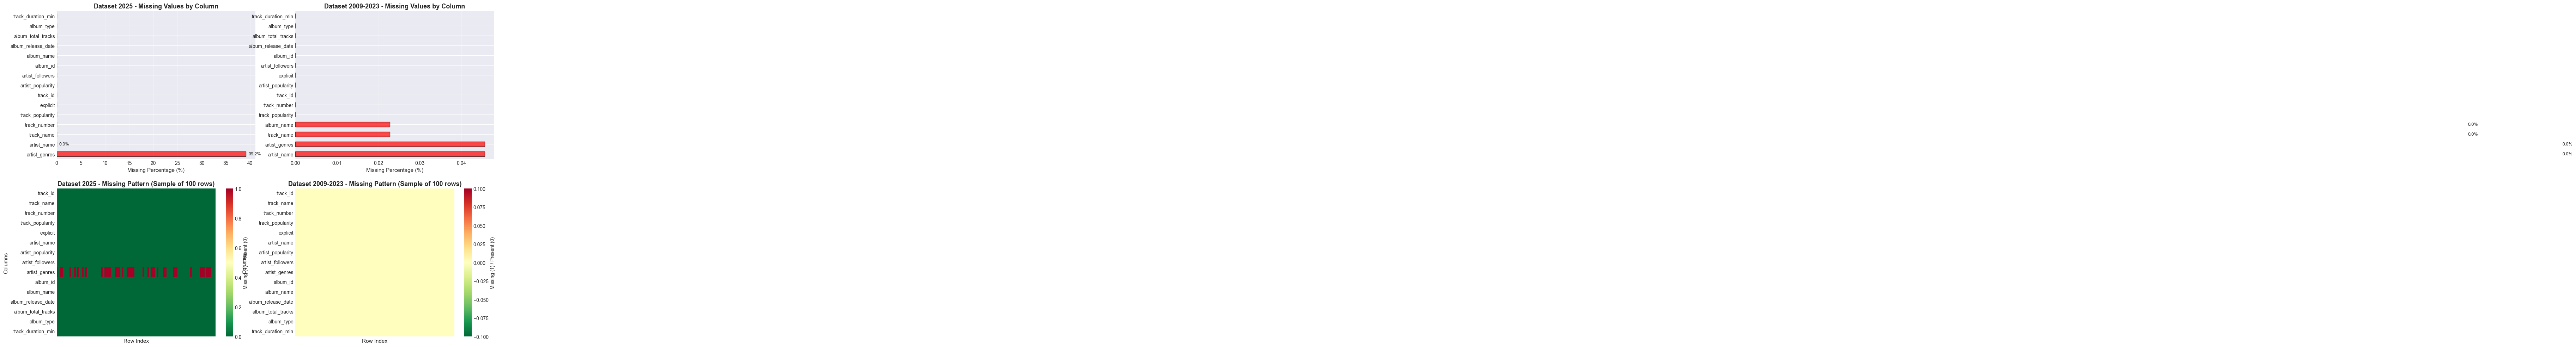

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

missing_pct_2025 = (df_2025.isnull().sum() / len(df_2025) * 100).sort_values(ascending=False)
colors_2025 = ['red' if x > 0 else 'green' for x in missing_pct_2025]
missing_pct_2025.plot(kind='barh', ax=axes[0, 0], color=colors_2025, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Missing Percentage (%)', fontsize=11)
axes[0, 0].set_title('Dataset 2025 - Missing Values by Column', fontsize=13, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')

for i, v in enumerate(missing_pct_2025):
    if v > 0:
        axes[0, 0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

missing_pct_2009 = (df_2009_2023.isnull().sum() / len(df_2009_2023) * 100).sort_values(ascending=False)
colors_2009 = ['red' if x > 0 else 'green' for x in missing_pct_2009]
missing_pct_2009.plot(kind='barh', ax=axes[0, 1], color=colors_2009, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Missing Percentage (%)', fontsize=11)
axes[0, 1].set_title('Dataset 2009-2023 - Missing Values by Column', fontsize=13, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')

for i, v in enumerate(missing_pct_2009):
    if v > 0:
        axes[0, 1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

sample_size = min(100, len(df_2025))
sample_indices = np.random.choice(df_2025.index, sample_size, replace=False)
missing_matrix_2025 = df_2025.loc[sample_indices].isnull().astype(int)

sns.heatmap(missing_matrix_2025.T, cmap='RdYlGn_r', cbar_kws={'label': 'Missing (1) / Present (0)'},
            ax=axes[1, 0], yticklabels=True, xticklabels=False)
axes[1, 0].set_title(f'Dataset 2025 - Missing Pattern (Sample of {sample_size} rows)', 
                      fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Row Index', fontsize=11)
axes[1, 0].set_ylabel('Columns', fontsize=11)

sample_size_2009 = min(100, len(df_2009_2023))
sample_indices_2009 = np.random.choice(df_2009_2023.index, sample_size_2009, replace=False)
missing_matrix_2009 = df_2009_2023.loc[sample_indices_2009].isnull().astype(int)

sns.heatmap(missing_matrix_2009.T, cmap='RdYlGn_r', cbar_kws={'label': 'Missing (1) / Present (0)'},
            ax=axes[1, 1], yticklabels=True, xticklabels=False)
axes[1, 1].set_title(f'Dataset 2009-2023 - Missing Pattern (Sample of {sample_size_2009} rows)', 
                      fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Row Index', fontsize=11)
axes[1, 1].set_ylabel('Columns', fontsize=11)

plt.tight_layout()
plt.show()

Biểu đồ cho thấy cột `artist_genres` có tỷ lệ missing cao nhất trong cả hai bộ dữ liệu. Heatmap giúp xác định xem có mẫu hình nào trong việc thiếu dữ liệu không.

### Phân tích mẫu hình dữ liệu thiếu

Kiểm tra xem dữ liệu thiếu có pattern hay là random.

In [64]:
print("Phan tich mau hinh du lieu thieu\n")

missing_per_row_2025 = df_2025.isnull().sum(axis=1)
print("Bộ dữ liệu 2025:")
print(f"  Dong co 0 gia tri thieu: {(missing_per_row_2025 == 0).sum():,} ({(missing_per_row_2025 == 0).sum()/len(df_2025)*100:.1f}%)")
print(f"  Dong co 1 gia tri thieu: {(missing_per_row_2025 == 1).sum():,} ({(missing_per_row_2025 == 1).sum()/len(df_2025)*100:.1f}%)")
print(f"  Dong co 2+ gia tri thieu: {(missing_per_row_2025 >= 2).sum():,} ({(missing_per_row_2025 >= 2).sum()/len(df_2025)*100:.1f}%)")
print(f"  So gia tri thieu toi da: {missing_per_row_2025.max()}")

missing_per_row_2009 = df_2009_2023.isnull().sum(axis=1)
print("\nBộ dữ liệu 2009-2023:")
print(f"  Dong co 0 gia tri thieu: {(missing_per_row_2009 == 0).sum():,} ({(missing_per_row_2009 == 0).sum()/len(df_2009_2023)*100:.1f}%)")
print(f"  Dong co 1 gia tri thieu: {(missing_per_row_2009 == 1).sum():,} ({(missing_per_row_2009 == 1).sum()/len(df_2009_2023)*100:.1f}%)")
print(f"  Dong co 2+ gia tri thieu: {(missing_per_row_2009 >= 2).sum():,} ({(missing_per_row_2009 >= 2).sum()/len(df_2009_2023)*100:.1f}%)")
print(f"  So gia tri thieu toi da: {missing_per_row_2009.max()}")

Phan tich mau hinh du lieu thieu

Bộ dữ liệu 2025:
  Dong co 0 gia tri thieu: 5,221 (60.8%)
  Dong co 1 gia tri thieu: 3,358 (39.1%)
  Dong co 2+ gia tri thieu: 3 (0.0%)
  So gia tri thieu toi da: 2

Bộ dữ liệu 2009-2023:
  Dong co 0 gia tri thieu: 8,772 (99.9%)
  Dong co 1 gia tri thieu: 0 (0.0%)
  Dong co 2+ gia tri thieu: 6 (0.1%)
  So gia tri thieu toi da: 2


### Phân tích tương quan giữa các cột thiếu dữ liệu

In [65]:
cols_with_missing_2025 = df_2025.columns[df_2025.isnull().any()].tolist()
cols_with_missing_2009 = df_2009_2023.columns[df_2009_2023.isnull().any()].tolist()

if len(cols_with_missing_2025) > 1:
    print("Bộ dữ liệu 2025 - Tương quan giữa các cột thiếu dữ liệu:")
    missing_corr_2025 = df_2025[cols_with_missing_2025].isnull().corr()
    print(missing_corr_2025.round(3))
elif len(cols_with_missing_2025) == 1:
    print(f"Bộ dữ liệu 2025 - Chi co mot cot co gia tri thieu: {cols_with_missing_2025[0]}")
else:
    print("Bộ dữ liệu 2025 - Khong co gia tri thieu")

if len(cols_with_missing_2009) > 1:
    print("\nBộ dữ liệu 2009-2023 - Tương quan giữa các cột thiếu dữ liệu:")
    missing_corr_2009 = df_2009_2023[cols_with_missing_2009].isnull().corr()
    print(missing_corr_2009.round(3))
elif len(cols_with_missing_2009) == 1:
    print(f"\nBộ dữ liệu 2009-2023 - Chi co mot cot co gia tri thieu: {cols_with_missing_2009[0]}")
else:
    print("\nBộ dữ liệu 2009-2023 - Khong co gia tri thieu")

Bộ dữ liệu 2025 - Tương quan giữa các cột thiếu dữ liệu:
               artist_name  artist_genres
artist_name           1.00           0.02
artist_genres         0.02           1.00

Bộ dữ liệu 2009-2023 - Tương quan giữa các cột thiếu dữ liệu:
               track_name  artist_name  artist_genres  album_name
track_name           1.00        -0.00          -0.00        1.00
artist_name         -0.00         1.00           1.00       -0.00
artist_genres       -0.00         1.00           1.00       -0.00
album_name           1.00        -0.00          -0.00        1.00


Tương quan cao (>0.5) giữa các cột thiếu dữ liệu cho thấy có mẫu hình thiếu có hệ thống. Tương quan thấp (<0.3) cho thấy dữ liệu thiếu ngẫu nhiên (MCAR - Missing Completely At Random).

## 2.5 Mối quan hệ và tương quan

Phần này sẽ được thực hiện trong các phân tích cụ thể cho từng câu hỏi nghiên cứu.

## 2.6 Quan sát và insight ban đầu

### Những phát hiện chính

1. **Chất lượng dữ liệu tốt:** Không có dòng trùng lặp hay dòng trống, các giá trị số đều nằm trong khoảng hợp lý
2. **Dữ liệu thiếu tập trung:** Chỉ có cột `artist_genres` có tỷ lệ missing cao (39% - 51%), các cột khác hoàn chỉnh
3. **Phân bố lệch:** Hầu hết các biến số có phân bố lệch phải, đặc biệt là `artist_followers` và các chỉ số popularity
4. **Outliers:** Có nhiều outliers trong `artist_followers` và `track_duration_min`, cần xem xét kỹ trong tiền xử lý
5. **Tính nhất quán:** Hai bộ dữ liệu có cấu trúc tương tự nhau, dễ dàng kết hợp nếu cần

### Vấn đề về chất lượng dữ liệu

1. **Missing values ở `artist_genres`:** Cần xử lý bằng imputation hoặc loại bỏ
2. **Outliers:** Cần quyết định giữ lại hay loại bỏ dựa trên context
3. **Rare categories:** Nhiều giá trị hiếm trong `artist_name` và `artist_genres` cần xem xét gộp nhóm

### Các bước tiền xử lý cần thiết

1. Xử lý missing values trong `artist_genres`
2. Xử lý outliers trong các cột số
3. Chuẩn hóa các cột categorical (nếu cần)
4. Tạo feature mới từ `album_release_date` (năm, quý, tháng)
5. Xem xét việc gộp các rare categories
6. Kết hợp hai bộ dữ liệu nếu cần phân tích xu hướng theo thời gian

### Những mẫu hình thú vị

1. Phân bố lệch phải của `artist_followers` cho thấy hiện tượng "superstar" - một số ít nghệ sĩ có lượng fan khổng lồ
2. Tỷ lệ explicit content ổn định ở mức 25% trong cả hai bộ dữ liệu
3. Album chiếm đa số (68%) so với single (26%), cho thấy nghệ sĩ vẫn ưa chuộng phát hành album đầy đủ
4. Missing pattern của `artist_genres` có thể liên quan đến nghệ sĩ mới hoặc nghệ sĩ độc lập chưa được phân loại rõ ràng